In [21]:
# @title 0. 环境设置与依赖项安装
# ------------------------------------------------------------------------------
# 清理、克隆、添加路径 (与之前一致)
# ------------------------------------------------------------------------------
!rm -rf /content/Time-Series-Library
!rm -rf /content/NAB
print("Cleaned up any existing Time-Series-Library and NAB directories.")
!git clone https://github.com/thuml/Time-Series-Library.git /content/Time-Series-Library -q
print("Time-Series-Library (containing TimesNet) repository cloned.")
!git clone https://github.com/numenta/NAB.git /content/NAB -q
print("NAB repository cloned.")
import sys
TIMESNET_PATH = '/content/Time-Series-Library'
if TIMESNET_PATH not in sys.path: sys.path.insert(0, TIMESNET_PATH)
print(f"Path '{TIMESNET_PATH}' added to sys.path.")

# ------------------------------------------------------------------------------
# 安装必要的依赖 (不再需要 statsmodels)
# ------------------------------------------------------------------------------
!pip install einops pandas numpy matplotlib scikit-learn torch torchvision torchaudio sympy -q
print("Installed/checked necessary packages.")

# ------------------------------------------------------------------------------
# 导入标准库
# ------------------------------------------------------------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler # 保留两者以供选择
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import json
import os
print("Imported standard libraries.")

# ------------------------------------------------------------------------------
# 导入 TimesNet 模型类 (与之前一致)
# ------------------------------------------------------------------------------
try:
    from models.TimesNet import Model as TimesNetModel
    print("Successfully imported TimesNet model class as TimesNetModel.")
except ImportError as e: print(f"ERROR: Could not import TimesNet model: {e}"); raise
except Exception as e_other: print(f"An unexpected error occurred during TimesNet import: {e_other}"); raise

# ------------------------------------------------------------------------------
# 设置设备 (与之前一致)
# ------------------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------------------------
# 打印环境信息 (与之前一致)
# ------------------------------------------------------------------------------
print(f"\n--- Environment Setup ---")
print(f"Using device: {device}")
print(f"PyTorch Version: {torch.__version__}")
# ... (CUDA info printout) ...
print(f"--- Setup Complete ---")

Cleaned up any existing Time-Series-Library and NAB directories.
Time-Series-Library (containing TimesNet) repository cloned.
NAB repository cloned.
Path '/content/Time-Series-Library' added to sys.path.
Installed/checked necessary packages.
Imported standard libraries.
Successfully imported TimesNet model class as TimesNetModel.

--- Environment Setup ---
Using device: cuda
PyTorch Version: 2.6.0+cu124
--- Setup Complete ---


--- Data Loading and Label Processing (NAB Dataset) ---
Attempting to load data for: artificialWithAnomaly/art_load_balancer_spikes.csv
Successfully loaded data from: /content/NAB/data/artificialWithAnomaly/art_load_balancer_spikes.csv
Found 1 raw anomaly window(s).
Label processing complete. Processed 1 window(s).
Total points marked as anomalous: 403

Prepared 'raw_time_series_values' (shape: (4032,)).
Prepared 'pointwise_true_labels' (anomalies: 403).


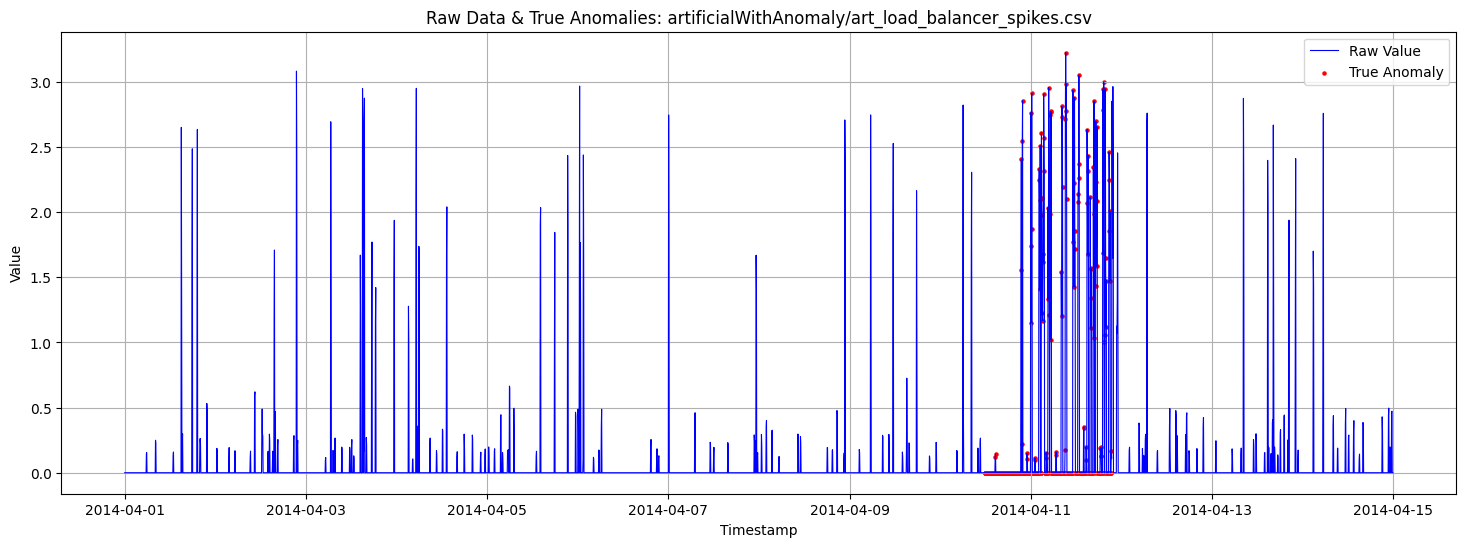

--- Data Loading and Label Processing Complete ---


In [22]:
# @title 1. NAB 数据加载与标签处理
# ------------------------------------------------------------------------------
# 用户指定参数
# ------------------------------------------------------------------------------
NAB_DATA_FILE_RELATIVE_PATH = 'artificialWithAnomaly/art_load_balancer_spikes.csv' # <--- 您选择的数据文件

DATA_FILE_COLAB_PATH = f'/content/NAB/data/{NAB_DATA_FILE_RELATIVE_PATH}'
LABEL_FILE_COLAB_PATH = '/content/NAB/labels/combined_windows.json'
JSON_KEY_FOR_LABELS = NAB_DATA_FILE_RELATIVE_PATH

print(f"--- Data Loading and Label Processing (NAB Dataset) ---")
print(f"Attempting to load data for: {NAB_DATA_FILE_RELATIVE_PATH}")

data_df = None
raw_time_series_values = None
pointwise_true_labels = None

if not os.path.exists(DATA_FILE_COLAB_PATH):
    print(f"ERROR: Data file not found: {DATA_FILE_COLAB_PATH}")
else:
    try:
        data_df_loaded = pd.read_csv(DATA_FILE_COLAB_PATH)
        print(f"Successfully loaded data from: {DATA_FILE_COLAB_PATH}")
        if 'timestamp' not in data_df_loaded.columns: raise ValueError("Column 'timestamp' not found.")
        data_df_loaded['timestamp'] = pd.to_datetime(data_df_loaded['timestamp'])
        data_df_loaded = data_df_loaded.set_index('timestamp')
        if 'value' not in data_df_loaded.columns: raise ValueError("Column 'value' not found.")
        data_df = data_df_loaded.copy() # Assign to data_df only after successful load and checks

        # Ensure 'value' column is numeric
        if not pd.api.types.is_numeric_dtype(data_df['value']):
             print(f"Warning: 'value' column is not numeric. Attempting conversion...")
             data_df['value'] = pd.to_numeric(data_df['value'], errors='coerce')
             if data_df['value'].isnull().all(): raise ValueError("'value' column is all NaN after conversion.")

    except Exception as e:
        print(f"Error during data loading or initial processing: {e}")
        data_df = None

if data_df is not None and 'value' in data_df.columns and not data_df['value'].isnull().all():
    # --- Label Processing Logic (identical to before) ---
    data_df['is_anomaly_pointwise'] = 0
    parsed_anomaly_windows_count = 0
    if not os.path.exists(LABEL_FILE_COLAB_PATH):
        print(f"WARNING: Label file not found: {LABEL_FILE_COLAB_PATH}.")
    else:
        try:
            with open(LABEL_FILE_COLAB_PATH, 'r') as f: all_labels_json = json.load(f)
            raw_anomaly_windows_list = all_labels_json.get(JSON_KEY_FOR_LABELS, [])
            if not raw_anomaly_windows_list: print(f"No anomaly windows found for key '{JSON_KEY_FOR_LABELS}'.")
            else:
                print(f"Found {len(raw_anomaly_windows_list)} raw anomaly window(s).")
                for window_event in raw_anomaly_windows_list:
                     if isinstance(window_event, list) and len(window_event) == 2:
                        try:
                            start_ts_str, end_ts_str = window_event
                            start_ts = pd.to_datetime(start_ts_str, errors='coerce')
                            end_ts = pd.to_datetime(end_ts_str, errors='coerce')
                            if pd.isna(start_ts) or pd.isna(end_ts): raise ValueError(f"Failed parse: {start_ts_str}, {end_ts_str}")
                            mask = (data_df.index >= start_ts) & (data_df.index <= end_ts)
                            data_df.loc[mask, 'is_anomaly_pointwise'] = 1
                            if mask.sum() > 0: parsed_anomaly_windows_count += 1
                        except Exception as e_win: print(f"  Warn: Couldn't process window {window_event}: {e_win}")
                print(f"Label processing complete. Processed {parsed_anomaly_windows_count} window(s).")
                print(f"Total points marked as anomalous: {data_df['is_anomaly_pointwise'].sum()}")
        except Exception as e_label: print(f"Label processing error: {e_label}")
    # --- End Label Processing ---

    raw_time_series_values = data_df['value'].values.copy() # Store original raw values
    pointwise_true_labels = data_df['is_anomaly_pointwise'].values.copy()
    print(f"\nPrepared 'raw_time_series_values' (shape: {raw_time_series_values.shape}).")
    print(f"Prepared 'pointwise_true_labels' (anomalies: {pointwise_true_labels.sum()}).")

    # --- Plotting Raw Data (identical to before) ---
    plt.figure(figsize=(18, 6))
    plt.plot(data_df.index, data_df['value'], label='Raw Value', color='blue', linewidth=0.8)
    anomalies_plot = data_df[data_df['is_anomaly_pointwise'] == 1]
    if not anomalies_plot.empty: plt.scatter(anomalies_plot.index, anomalies_plot['value'], color='red', label='True Anomaly', marker='.', s=20)
    plt.title(f"Raw Data & True Anomalies: {JSON_KEY_FOR_LABELS}"); plt.xlabel("Timestamp"); plt.ylabel("Value"); plt.legend(); plt.grid(True); plt.show()
    # --- End Plotting ---

elif data_df is not None: print("ERROR: 'value' column missing or all NaN.")
else: print("Data loading failed.")

print(f"--- Data Loading and Label Processing Complete ---")


--- Moving Average Smoothing (on Raw Data) ---
Applying Moving Average with window size 5 to the raw data...
Moving Average smoothing of raw data complete.
  Smoothed raw data length: 4032
  NaNs in smoothed raw data (after fill): 0


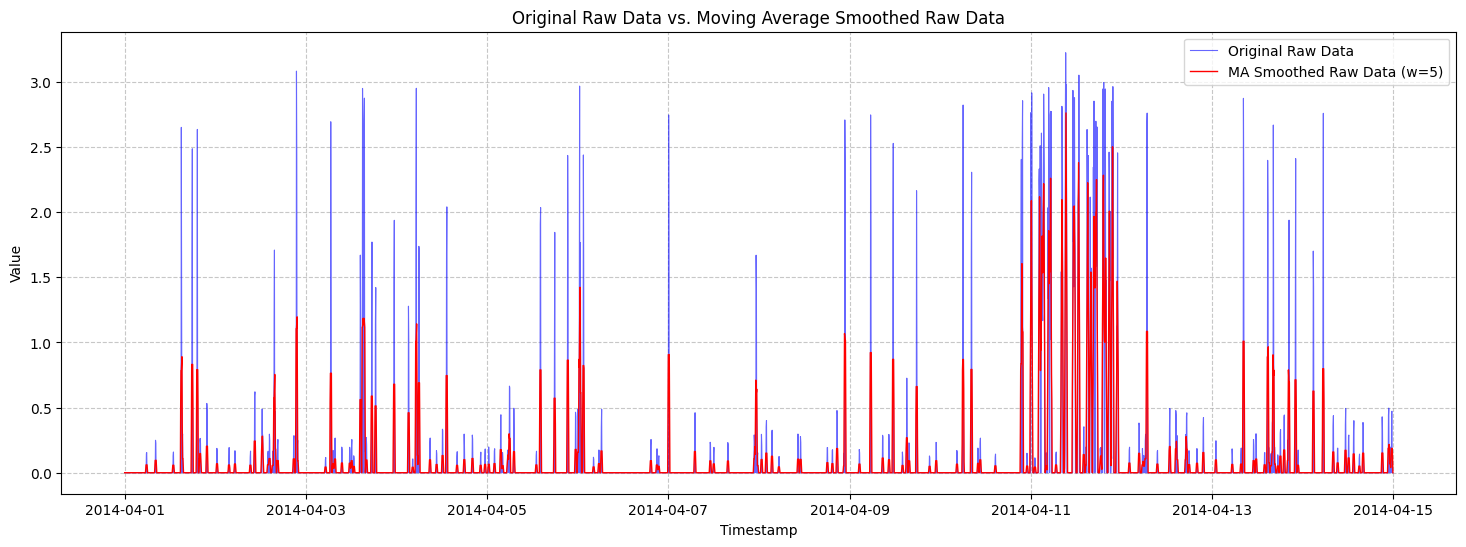

MA Smoothed raw data joined to data_df.
--- Moving Average Smoothing Complete ---


In [23]:
# @title 2. 移动平均平滑 (应用于原始数据)
# ------------------------------------------------------------------------------
# 直接对原始时间序列 data_df['value'] 应用 Moving Average 平滑
# ------------------------------------------------------------------------------
print(f"\n--- Moving Average Smoothing (on Raw Data) ---")

df_raw_ma_smoothed = None
raw_ma_smoothed_values = None # 将持有 MA 平滑后的 *原始* 数据值

# 确保 data_df['value'] 存在且有效
if data_df is not None and 'value' in data_df.columns and not data_df['value'].isnull().all():

    # --- Moving Average Calculation ---
    # *** 重要参数: MA_WINDOW_SIZE ***
    MA_WINDOW_SIZE = 5 # <--- 调整窗口大小进行实验！
    print(f"Applying Moving Average with window size {MA_WINDOW_SIZE} to the raw data...")

    # 计算移动平均
    raw_ma_series = data_df['value'].rolling(window=MA_WINDOW_SIZE, center=True, min_periods=1).mean()

    # 填充 MA 产生的 NaN 值
    raw_ma_series_filled = raw_ma_series.bfill().ffill()
    if raw_ma_series_filled.isnull().any():
         print("  Warning: Filling remaining NaNs in MA smoothed raw data with 0.")
         raw_ma_series_filled.fillna(0, inplace=True)

    raw_ma_smoothed_values = raw_ma_series_filled.values
    # 创建一个包含平滑后值的 DataFrame，索引与原始数据一致
    df_raw_ma_smoothed = pd.DataFrame({'value_ma_smoothed': raw_ma_smoothed_values}, index=data_df.index)
    # --- End Moving Average Calculation ---

    print(f"Moving Average smoothing of raw data complete.")
    print(f"  Smoothed raw data length: {len(raw_ma_smoothed_values)}")
    print(f"  NaNs in smoothed raw data (after fill): {np.isnan(raw_ma_smoothed_values).sum()}")

    # 可视化原始数据和平滑后的数据
    plt.figure(figsize=(18, 6))
    plt.plot(data_df.index, data_df['value'], label='Original Raw Data', color='blue', alpha=0.6, linewidth=0.8)
    if df_raw_ma_smoothed is not None and not df_raw_ma_smoothed.empty:
         plt.plot(df_raw_ma_smoothed.index, df_raw_ma_smoothed['value_ma_smoothed'], label=f'MA Smoothed Raw Data (w={MA_WINDOW_SIZE})', color='red', linewidth=1.0)
    plt.title('Original Raw Data vs. Moving Average Smoothed Raw Data')
    plt.xlabel('Timestamp')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    # 更新 data_df (可选)
    if data_df is not None and df_raw_ma_smoothed is not None:
        # 移除可能存在的旧列
        if 'value_ma_smoothed' in data_df.columns: data_df = data_df.drop(columns=['value_ma_smoothed'])
        # 移除季节性分解或之前平滑可能添加的列
        cols_to_remove = ['trend', 'seasonal', 'residual', 'trend_smoothed', 'residual_smoothed', 'residual_ma_smoothed']
        data_df = data_df.drop(columns=[col for col in cols_to_remove if col in data_df.columns], errors='ignore')
        # 加入新的平滑列
        data_df = data_df.join(df_raw_ma_smoothed)
        print("MA Smoothed raw data joined to data_df.")

else:
    print("Raw data ('value' column in data_df) is not available or empty. Skipping Moving Average smoothing.")
    raw_ma_smoothed_values = None # 标记为不可用

print(f"--- Moving Average Smoothing Complete ---")

In [24]:
# @title 3. 数据准备 (缩放、窗口化、窗口级别标签 - 基于MA平滑后原始数据)
# ------------------------------------------------------------------------------
# 使用 Moving Average 平滑后的 *原始* 数据作为 TimesNet 的输入
# ------------------------------------------------------------------------------
print(f"\n--- Data Preparation for TimesNet (Scaling, Windowing, Labels on MA Smoothed Raw Data) ---")
X_tensor = None
dataloader = None
window_level_true_labels_for_model = None # 标签始终基于原始标签数据
WINDOW_SIZE = None
time_series_for_model_scaled = None
X_windowed_data_np = None
input_series_for_timesnet = None # 这是将要被缩放和窗口化的序列

# 决定使用哪个时间序列进行 TimesNet 输入
# 优先使用 MA 平滑后的原始数据
if raw_ma_smoothed_values is not None and len(raw_ma_smoothed_values) > 0:
    # MA 处理后理论上不应有 NaN，但检查以防万一
    if np.isnan(raw_ma_smoothed_values).all():
        print("Warning: MA Smoothed raw data is all NaN. Falling back to original raw data.")
        input_series_for_timesnet = raw_time_series_values # Fallback to original raw
    else:
        input_series_for_timesnet = raw_ma_smoothed_values
        print("Using MA smoothed raw data as input for TimesNet.")

# 如果 MA 平滑数据不可用，则直接使用原始数据
elif raw_time_series_values is not None and len(raw_time_series_values) > 0:
    print("MA Smoothed raw data is not available. Using original raw time series values for TimesNet.")
    input_series_for_timesnet = raw_time_series_values
else:
    print("ERROR: No suitable time series (MA smoothed or raw) available. Cannot proceed.")
    input_series_for_timesnet = None

# --- 后续处理: NaN填充, 缩放, 窗口化, DataLoader创建 ---
if input_series_for_timesnet is not None:
    # 1. 确保是一维并填充NaN (必须在缩放前)
    # (即使 MA 填充过，原始数据 fallback 也可能需要填充)
    temp_series_pd = pd.Series(input_series_for_timesnet.flatten())
    temp_series_pd.ffill(inplace=True)
    temp_series_pd.bfill(inplace=True)
    if temp_series_pd.isnull().any():
        print("Warning: Filling remaining NaNs in input series with 0 before scaling.")
        temp_series_pd.fillna(0, inplace=True)
    input_series_for_timesnet_filled = temp_series_pd.values.reshape(-1, 1)

    # 2. 检查长度对齐 (与原始 pointwise_true_labels)
    if pointwise_true_labels is not None and len(input_series_for_timesnet_filled) != len(pointwise_true_labels):
        print(f"CRITICAL WARNING: Length mismatch! Input: {len(input_series_for_timesnet_filled)}, Labels: {len(pointwise_true_labels)}. Reconciling.")
        min_len = min(len(input_series_for_timesnet_filled), len(pointwise_true_labels))
        input_series_for_timesnet_filled = input_series_for_timesnet_filled[:min_len]
        pointwise_true_labels = pointwise_true_labels[:min_len]
        if data_df is not None and len(data_df) > min_len: data_df = data_df.iloc[:min_len]

    if len(input_series_for_timesnet_filled) > 0 and pointwise_true_labels is not None:
        # 3. 缩放 (MinMaxScaler 或 StandardScaler)
        scaler = MinMaxScaler(feature_range=(0, 1))
        # scaler = StandardScaler() # 可以切换使用
        print(f"Using {type(scaler).__name__} for scaling.")
        time_series_for_model_scaled = scaler.fit_transform(input_series_for_timesnet_filled)
        print(f"Input data for TimesNet (based on MA raw) scaled. Shape: {time_series_for_model_scaled.shape}")

        # 4. 窗口化和 DataLoader 创建 (与之前逻辑一致)
        WINDOW_SIZE = 96 # 常用值, 可调
        print(f"Using WINDOW_SIZE (seq_len for TimesNet): {WINDOW_SIZE}")

        if len(time_series_for_model_scaled) < WINDOW_SIZE:
            print(f"ERROR: Data length ({len(time_series_for_model_scaled)}) < WINDOW_SIZE ({WINDOW_SIZE}).")
        else:
            def create_windows_for_timesnet(input_data, window_length):
                windows = []
                for i in range(len(input_data) - window_length + 1):
                    windows.append(input_data[i : i + window_length])
                return np.array(windows)

            X_windowed_data_np = create_windows_for_timesnet(time_series_for_model_scaled, WINDOW_SIZE)

            if X_windowed_data_np.shape[0] > 0:
                print(f"Created windows. Shape: {X_windowed_data_np.shape}")
                X_tensor = torch.tensor(X_windowed_data_np, dtype=torch.float32).to(device)
                y_tensor_target = X_tensor.detach().clone() # 重构目标是自身
                print(f"X_tensor shape: {X_tensor.shape}, y_tensor_target shape: {y_tensor_target.shape}")

                # 创建窗口级别标签 (基于原始的 pointwise_true_labels)
                num_windows = X_windowed_data_np.shape[0]; temp_window_labels = []
                if len(pointwise_true_labels) >= WINDOW_SIZE:
                     for i in range(num_windows):
                         if i + WINDOW_SIZE <= len(pointwise_true_labels):
                             orig_labels = pointwise_true_labels[i : i + WINDOW_SIZE]
                             is_anom = np.any(orig_labels == 1)
                             temp_window_labels.append(1 if is_anom else 0)
                         else: temp_window_labels.append(0) # Should not happen
                     window_level_true_labels_for_model = np.array(temp_window_labels)
                     print(f"Created window labels. Shape: {window_level_true_labels_for_model.shape}, Anomalous windows: {window_level_true_labels_for_model.sum()}")
                else: print(f"Warn: Labels too short."); window_level_true_labels_for_model = np.zeros(num_windows, dtype=int)

                # 创建 DataLoader
                BATCH_SIZE_MODEL = 32
                dataset = TensorDataset(X_tensor, y_tensor_target)
                dataloader = DataLoader(dataset, batch_size=BATCH_SIZE_MODEL, shuffle=True)
                print(f"DataLoader created with batch size {BATCH_SIZE_MODEL}.")
            else: print("No windows were created.")
    else: print("Skipping TimesNet preparation: Input empty or labels missing after alignment.")
else: print("Skipping TimesNet preparation: No suitable input series.")

print(f"--- Data Preparation for TimesNet (on MA Smoothed Raw Data) Complete ---")


--- Data Preparation for TimesNet (Scaling, Windowing, Labels on MA Smoothed Raw Data) ---
Using MA smoothed raw data as input for TimesNet.
Using MinMaxScaler for scaling.
Input data for TimesNet (based on MA raw) scaled. Shape: (4032, 1)
Using WINDOW_SIZE (seq_len for TimesNet): 96
Created windows. Shape: (3937, 96, 1)
X_tensor shape: torch.Size([3937, 96, 1]), y_tensor_target shape: torch.Size([3937, 96, 1])
Created window labels. Shape: (3937,), Anomalous windows: 498
DataLoader created with batch size 32.
--- Data Preparation for TimesNet (on MA Smoothed Raw Data) Complete ---


In [25]:
# @title 4. TimesNet 模型定义
# ------------------------------------------------------------------------------
print(f"\n--- TimesNet Model Definition ---")
model = None
if WINDOW_SIZE is not None and X_tensor is not None and X_tensor.nelement() > 0 :
    class TimesNetConfigs: # (Config class definition identical to before)
        def __init__(self, current_window_size, num_features=1):
            self.seq_len = current_window_size; self.pred_len = 0
            self.enc_in = num_features; self.c_out = num_features
            self.d_model = 64; self.d_ff = 64; self.num_kernels = 6
            self.e_layers = 2; self.top_k = 5; self.dropout = 0.1
            self.task_name = 'anomaly_detection'; self.embed = 'fixed'
            self.freq = 'h'; self.output_attention = False; self.label_len = 0
    try:
        n_features_model = 1 # Assuming univariate
        model_configs = TimesNetConfigs(WINDOW_SIZE, num_features=n_features_model)
        model = TimesNetModel(model_configs).float().to(device)
        print("TimesNet model instantiated.")
        if list(model.parameters()): print(f"Model is on device: {next(model.parameters()).device}")
        else: print("Warning: Model has no parameters.")
    except Exception as e_model_init: print(f"ERROR instantiating TimesNet: {e_model_init}"); model = None
else: print("Cannot instantiate TimesNet model: Check Module 3 for WINDOW_SIZE or X_tensor.")
print(f"--- Model Definition Complete ---")


--- TimesNet Model Definition ---
TimesNet model instantiated.
Model is on device: cuda:0
--- Model Definition Complete ---



--- Model Training (TimesNet for Reconstruction) ---
Starting training TimesNet for 10 epochs...
Epoch [1/10], Loss: 0.0007551
Epoch [2/10], Loss: 0.0001139
Epoch [3/10], Loss: 0.0000666
Epoch [4/10], Loss: 0.0000617
Epoch [5/10], Loss: 0.0000397
Epoch [6/10], Loss: 0.0000678
Epoch [7/10], Loss: 0.0000409
Epoch [8/10], Loss: 0.0000368
Epoch [9/10], Loss: 0.0000413
Epoch [10/10], Loss: 0.0000792
Training finished.


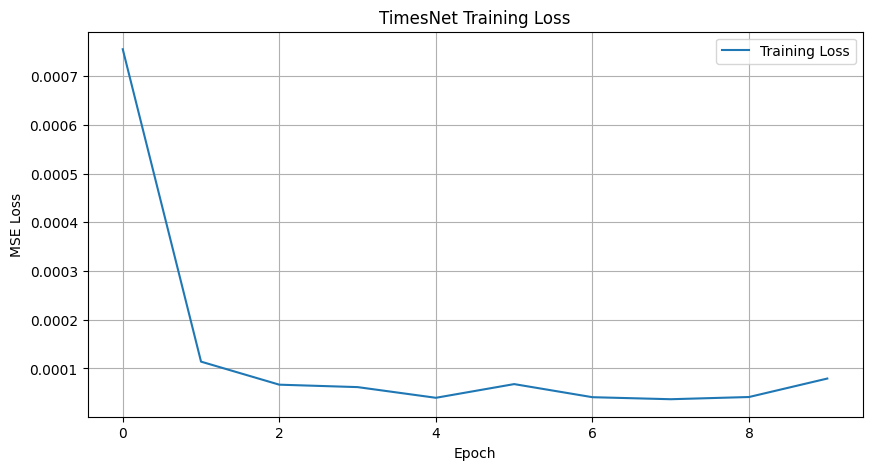

--- Model Training Complete ---


In [26]:
# @title 5. 模型训练 (TimesNet for Reconstruction)
# ------------------------------------------------------------------------------
print(f"\n--- Model Training (TimesNet for Reconstruction) ---")
history = {'train_loss': []}
if model is not None and dataloader is not None :
    NUM_EPOCHS_TIMESNET = 10; LEARNING_RATE_TIMESNET = 0.001
    criterion = nn.MSELoss(); optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE_TIMESNET)
    print(f"Starting training TimesNet for {NUM_EPOCHS_TIMESNET} epochs...")
    for epoch in range(NUM_EPOCHS_TIMESNET): # (Training loop identical to before)
        model.train(); epoch_loss = 0
        for batch_x, batch_y_true_reconstruction in dataloader:
            optimizer.zero_grad()
            dec_inp_dummy = torch.zeros_like(batch_x).float().to(device)
            outputs = model(batch_x, None, dec_inp_dummy, None)
            loss = criterion(outputs, batch_y_true_reconstruction)
            loss.backward(); optimizer.step(); epoch_loss += loss.item()
        avg_epoch_loss = epoch_loss / len(dataloader); history['train_loss'].append(avg_epoch_loss)
        if (epoch + 1) % 1 == 0 or epoch == NUM_EPOCHS_TIMESNET - 1 : print(f"Epoch [{epoch+1}/{NUM_EPOCHS_TIMESNET}], Loss: {avg_epoch_loss:.7f}")
    print("Training finished.")
    plt.figure(figsize=(10, 5)); plt.plot(history['train_loss'], label='Training Loss'); plt.title('TimesNet Training Loss'); plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.legend(); plt.grid(True); plt.show()
else: print("Skipping model training: model or dataloader not available.")
print(f"--- Model Training Complete ---")


--- Anomaly Score Calculation (TimesNet Reconstruction Error on MA Raw Data) ---
Calculated anomaly scores for 3937 sequences.
Anomaly scores mapped to time points.


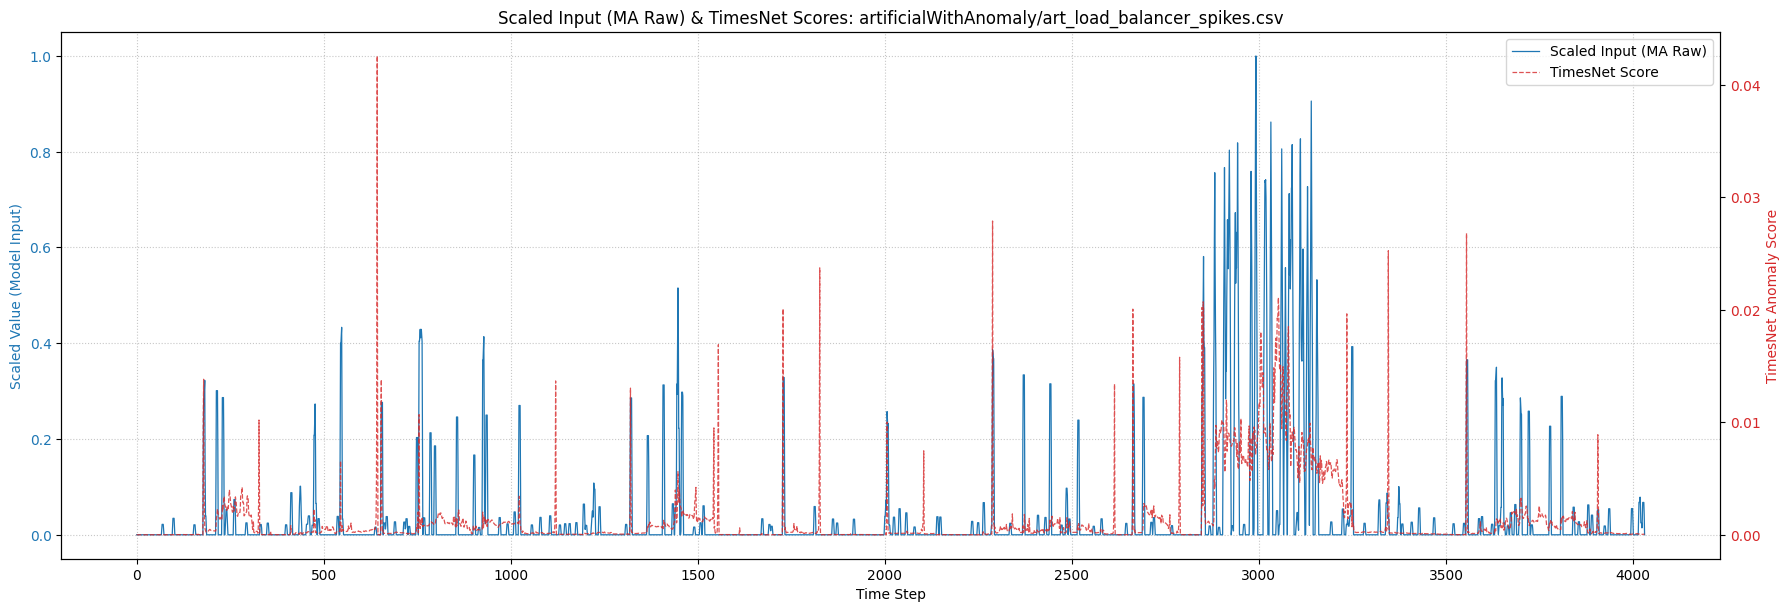

--- Anomaly Score Calculation Complete ---


In [27]:
# @title 6. 异常分数计算 (TimesNet 重构误差)
# ------------------------------------------------------------------------------
print(f"\n--- Anomaly Score Calculation (TimesNet Reconstruction Error on MA Raw Data) ---")
anomaly_scores_per_sequence = None
anomaly_scores_timesnet_pointwise = None

if (model is not None and X_tensor is not None and X_tensor.size(0) > 0 and WINDOW_SIZE is not None and time_series_for_model_scaled is not None and len(time_series_for_model_scaled) > 0):
    # (Score calculation logic identical to before)
    model.eval(); temp_anomaly_scores_per_sequence = []
    eval_dataset_tsn = TensorDataset(X_tensor, X_tensor)
    eval_dataloader_tsn = DataLoader(eval_dataset_tsn, batch_size=BATCH_SIZE_MODEL, shuffle=False)
    reconstruction_criterion_none = nn.MSELoss(reduction='none').to(device)
    with torch.no_grad():
        for batch_x, _ in eval_dataloader_tsn:
            dec_inp_dummy_eval = torch.zeros_like(batch_x).float().to(device)
            reconstruction = model(batch_x, None, dec_inp_dummy_eval, None)
            loss_pointwise = reconstruction_criterion_none(reconstruction, batch_x)
            loss_per_timestep = loss_pointwise.mean(dim=-1)
            current_batch_anomaly_scores = loss_per_timestep.max(dim=-1)[0]
            temp_anomaly_scores_per_sequence.extend(current_batch_anomaly_scores.cpu().numpy())
    anomaly_scores_per_sequence = np.array(temp_anomaly_scores_per_sequence)
    print(f"Calculated anomaly scores for {len(anomaly_scores_per_sequence)} sequences.")

    # --- Map scores back (logic identical) ---
    anomaly_scores_timesnet_pointwise = np.full(len(time_series_for_model_scaled), np.nan)
    num_expected_sequences = len(time_series_for_model_scaled) - WINDOW_SIZE + 1
    # (Mapping and fallback logic identical to previous versions)
    if len(anomaly_scores_per_sequence) == num_expected_sequences:
        for i in range(len(anomaly_scores_per_sequence)): anomaly_scores_timesnet_pointwise[i + WINDOW_SIZE - 1] = anomaly_scores_per_sequence[i]
        first_valid = np.where(~np.isnan(anomaly_scores_timesnet_pointwise))[0]
        if len(first_valid) > 0: anomaly_scores_timesnet_pointwise[:first_valid[0]] = anomaly_scores_timesnet_pointwise[first_valid[0]]
        else: anomaly_scores_timesnet_pointwise[:] = 0
        print("Anomaly scores mapped to time points.")
    elif len(anomaly_scores_per_sequence) > 0 :
        print(f"Warn: Score length mismatch. Expected {num_expected_sequences}, got {len(anomaly_scores_per_sequence)}. Partial fill.")
        fill_len = min(len(anomaly_scores_per_sequence), num_expected_sequences)
        if fill_len > 0 :
            for i in range(fill_len): anomaly_scores_timesnet_pointwise[i + WINDOW_SIZE - 1] = anomaly_scores_per_sequence[i]
            first_valid = np.where(~np.isnan(anomaly_scores_timesnet_pointwise))[0]
            if len(first_valid) > 0: anomaly_scores_timesnet_pointwise[:first_valid[0]] = anomaly_scores_timesnet_pointwise[first_valid[0]]
            else: anomaly_scores_timesnet_pointwise[:] = 0
        else: anomaly_scores_timesnet_pointwise[:] = 0
        print("Partial mapping complete.")
    else:
        print("No scores calculated. Filling with zeros.")
        anomaly_scores_timesnet_pointwise = np.zeros(len(time_series_for_model_scaled))
    # --- End Mapping ---

    # --- Plotting Scores vs Scaled Input (update title) ---
    if (time_series_for_model_scaled is not None and len(time_series_for_model_scaled) > 0 and anomaly_scores_timesnet_pointwise is not None and len(anomaly_scores_timesnet_pointwise) == len(time_series_for_model_scaled)):
        fig, ax1 = plt.subplots(figsize=(18, 6))
        color = 'tab:blue'; ax1.set_xlabel('Time Step'); ax1.set_ylabel('Scaled Value (Model Input)', color=color)
        ax1.plot(time_series_for_model_scaled, color=color, label='Scaled Input (MA Raw)', linewidth=0.9); ax1.tick_params(axis='y', labelcolor=color); ax1.grid(True, linestyle=':', alpha=0.7)
        ax2 = ax1.twinx(); color = 'tab:red'; ax2.set_ylabel('TimesNet Anomaly Score', color=color)
        ax2.plot(anomaly_scores_timesnet_pointwise, color=color, label='TimesNet Score', linestyle='--', linewidth=0.9, alpha=0.8); ax2.tick_params(axis='y', labelcolor=color)
        fig.tight_layout(); plt.title(f'Scaled Input (MA Raw) & TimesNet Scores: {NAB_DATA_FILE_RELATIVE_PATH}')
        lines, labels = ax1.get_legend_handles_labels(); lines2, labels2 = ax2.get_legend_handles_labels(); ax2.legend(lines + lines2, labels + labels2, loc='best'); plt.show()
    else: print("Could not plot scores: data missing or lengths mismatch.")
    # --- End Plotting ---
else: print("Skipping score calculation: prerequisites not met.")
print(f"--- Anomaly Score Calculation Complete ---")

In [28]:
# @title 7. 阈值设定与评估 (窗口级别 - TimesNet)
# ------------------------------------------------------------------------------
print(f"\n--- Thresholding and Evaluation (TimesNet on Window-Level) ---")
predicted_window_anomalies_bool_tsn = None
if (anomaly_scores_per_sequence is not None and window_level_true_labels_for_model is not None and len(anomaly_scores_per_sequence) == len(window_level_true_labels_for_model) and len(window_level_true_labels_for_model) > 0 and WINDOW_SIZE is not None):
    threshold_percentile = 0.95 # (Thresholding logic identical to before)
    if len(anomaly_scores_per_sequence) > 0: threshold_timesnet = np.quantile(anomaly_scores_per_sequence, threshold_percentile)
    else: threshold_timesnet = 0
    print(f"Anomaly threshold ({threshold_percentile*100:.0f}th percentile): {threshold_timesnet:.6f}")
    predicted_window_anomalies_bool_tsn = anomaly_scores_per_sequence > threshold_timesnet
    predicted_window_anomalies_int_tsn = predicted_window_anomalies_bool_tsn.astype(int)
    # (Evaluation metric calculation identical to before)
    precision, recall, f1, _ = precision_recall_fscore_support(window_level_true_labels_for_model, predicted_window_anomalies_int_tsn, average='binary', zero_division=0)
    cm = confusion_matrix(window_level_true_labels_for_model, predicted_window_anomalies_int_tsn)
    print(f"\nEvaluation Results (TimesNet, Window-Level for '{NAB_DATA_FILE_RELATIVE_PATH}'):")
    # Update the preprocessing description
    print(f"  Preprocessing: Moving Average on Raw Data (Window={MA_WINDOW_SIZE if 'MA_WINDOW_SIZE' in locals() else 'N/A'})")
    print(f"  Window size (seq_len): {WINDOW_SIZE}")
    # (Rest of printout identical)
    print(f"  Windows evaluated: {len(window_level_true_labels_for_model)}")
    print(f"  True anomalous windows: {window_level_true_labels_for_model.sum()}")
    print(f"  Predicted anomalous windows: {predicted_window_anomalies_int_tsn.sum()}")
    print(f"  Precision: {precision:.4f}"); print(f"  Recall:    {recall:.4f}"); print(f"  F1-Score:  {f1:.4f}")
    print(f"  Confusion Matrix:\n{cm}")
    if cm.size == 4: tn, fp, fn, tp = cm.ravel(); print(f"    TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
    else: print(f"    CM shape {cm.shape} not 2x2.")
else: print("Skipping window-level evaluation: prerequisites missing or data mismatch.")
print(f"--- Thresholding and Evaluation Complete ---")


--- Thresholding and Evaluation (TimesNet on Window-Level) ---
Anomaly threshold (95th percentile): 0.007974

Evaluation Results (TimesNet, Window-Level for 'artificialWithAnomaly/art_load_balancer_spikes.csv'):
  Preprocessing: Moving Average on Raw Data (Window=5)
  Window size (seq_len): 96
  Windows evaluated: 3937
  True anomalous windows: 498
  Predicted anomalous windows: 197
  Precision: 0.8376
  Recall:    0.3313
  F1-Score:  0.4748
  Confusion Matrix:
[[3407   32]
 [ 333  165]]
    TN: 3407, FP: 32, FN: 333, TP: 165
--- Thresholding and Evaluation Complete ---



--- Final Visualization (TimesNet on Raw Data with Detected Windows based on MA Raw Data) ---


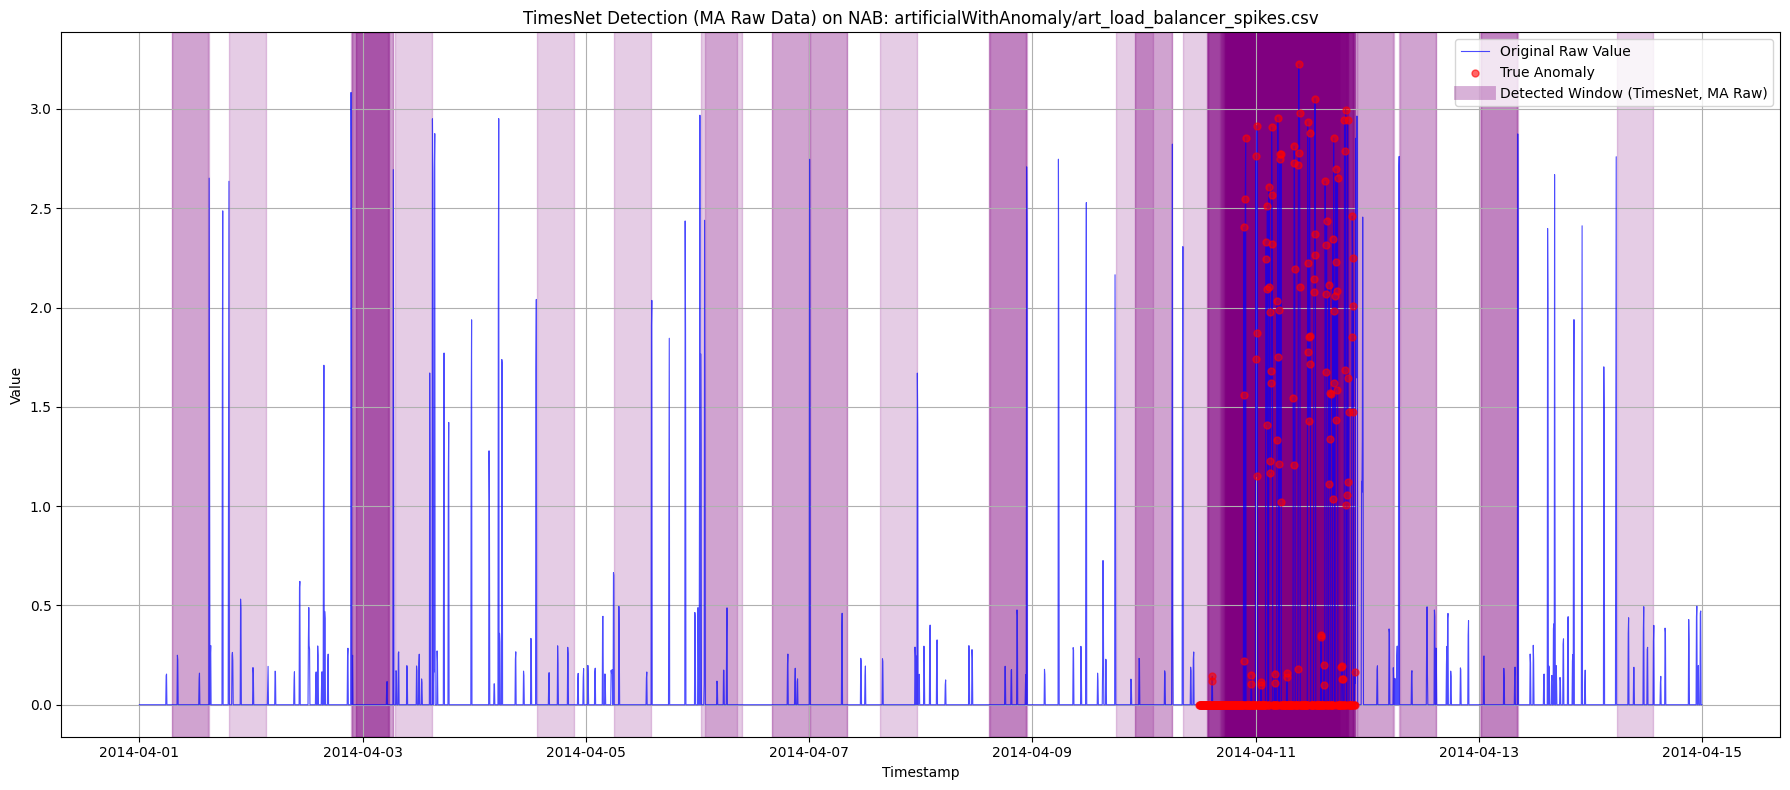

--- Visualization Complete ---

--- End of Script (with MA Preprocessing on Raw Data) ---


In [29]:
# @title 8. 最终可视化 (原始数据上的异常窗口 - TimesNet)
# ------------------------------------------------------------------------------
print(f"\n--- Final Visualization (TimesNet on Raw Data with Detected Windows based on MA Raw Data) ---")
if (data_df is not None and not data_df.empty and 'value' in data_df.columns and WINDOW_SIZE is not None and predicted_window_anomalies_bool_tsn is not None and X_windowed_data_np is not None and X_windowed_data_np.shape[0] > 0 and len(predicted_window_anomalies_bool_tsn) == X_windowed_data_np.shape[0] and len(data_df.index) >= WINDOW_SIZE):
    plt.figure(figsize=(18, 8)) # (Plotting logic identical to before)
    # Plot raw data
    plt.plot(data_df.index, data_df['value'], label='Original Raw Value', color='blue', linewidth=0.8, alpha=0.7)
    # Plot true anomalies
    if 'is_anomaly_pointwise' in data_df.columns:
        true_anomalies_plot = data_df[data_df['is_anomaly_pointwise'] == 1]
        if not true_anomalies_plot.empty: plt.scatter(true_anomalies_plot.index, true_anomalies_plot['value'], color='red', label='True Anomaly', marker='o', s=25, alpha=0.6, zorder=3)
    # Plot detected anomalous windows
    num_windows = X_windowed_data_np.shape[0]; detected_marked = False
    for i in range(num_windows):
        if predicted_window_anomalies_bool_tsn[i]:
            if i + WINDOW_SIZE <= len(data_df.index):
                start_t = data_df.index[i]; end_t = data_df.index[i + WINDOW_SIZE - 1]
                plt.axvspan(start_t, end_t, color='purple', alpha=0.2, label='_nolegend_'); detected_marked = True
            else: print(f"  Warn: Window {i} out of bounds for plot.")
    if detected_marked: plt.plot([], [], color='purple', alpha=0.3, linewidth=10, label=f'Detected Window (TimesNet, MA Raw)')
    # Update title
    plt.title(f"TimesNet Detection (MA Raw Data) on NAB: {NAB_DATA_FILE_RELATIVE_PATH}")
    plt.xlabel("Timestamp"); plt.ylabel("Value"); plt.legend(loc='best'); plt.grid(True); plt.tight_layout(); plt.show()
else: print("Skipping final visualization: prerequisites not met or inconsistent data.")
print(f"--- Visualization Complete ---")
print("\n--- End of Script (with MA Preprocessing on Raw Data) ---")